In [ ]:
!git clone https://github.com/dekii2275/CV_trafficdetection.git

Cloning into 'testtt'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 77 (delta 43), reused 15 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 24.28 KiB | 3.47 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [7]:
!cp -r /kaggle/input/data-set-vehicle/* ./

In [1]:
import yaml
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import seaborn as sns

In [2]:
import numpy as np
import pandas as pd

In [10]:
import sys
import os


package_path = '/kaggle/working/testtt'

sys.path.append(package_path)

# Kiểm tra xem đã nhận chưa
print(os.listdir(package_path))

['README.md', '.git', '.DS_Store', 'model_detection']


In [ ]:
data_config = {
    'path': '/kaggle/working',  # Đường dẫn gốc (quan trọng cho YOLOv8)
    'train': '/kaggle/working/train/images',
    'val': '/kaggle/working/valid/images',
    'test': '/kaggle/working/test/images', # Nếu có
    
   
    'nc': 8,
    
    
    'names': ['0', '1', '2', '3', 'bus', 'car', 'motor', 'truck']
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

In [12]:
from model_detection.data.data_preprocessor import load_data_set,verify_image_label_pairs,compute_dataset_stats,clip_and_fix_boxes,remap_yolo_labels,visualize_image_with_bbox,get_one_image_per_class
from model_detection.model.model_trainer import load_training_config,train_model,valid_model
from model_detection.model.yolo_detector import YOLODetector

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [13]:
data_yaml_path = '/kaggle/working/data.yaml'
data_set = load_data_set(data_yaml_path)
print(data_set)
print("Dataset loaded successfully!")
print("Train images:", data_set['train_images'])
print("Validation images:", data_set['val_images'])
print("Class names:", data_set['names'])
print("Number of classes:", data_set['nc'])
print(compute_dataset_stats(data_set['train_images'],data_set['train_labels']))
print(verify_image_label_pairs(data_set['train_images'],data_set['train_labels']))

{'train_images': '/kaggle/working/train/images', 'val_images': '/kaggle/working/valid/images', 'test_images': '/kaggle/working/test/images', 'names': ['0', '1', '2', '3', 'bus', 'car', 'motor', 'truck'], 'nc': 8, 'train_labels': '/kaggle/working/train/labels', 'val_labels': '/kaggle/working/valid/labels', 'test_labels': '/kaggle/working/test/labels'}
Dataset loaded successfully!
Train images: /kaggle/working/train/images
Validation images: /kaggle/working/valid/images
Class names: ['0', '1', '2', '3', 'bus', 'car', 'motor', 'truck']
Number of classes: 8
{'num_images': 1235, 'num_labels': 5795, 'classes': [0, 1, 2, 3, 4, 5, 6, 7], 'labels_per_class': {0: 1343, 1: 206, 2: 197, 3: 126, 6: 1583, 7: 1224, 5: 918, 4: 198}, 'small_boxes': 2286, 'small_box_ratio': 0.39447799827437446}
[]


In [14]:
remap_yolo_labels(
    [data_set['train_labels']],id_map={5: 0, 6: 1, 7: 2, 4: 3}
)
remap_yolo_labels(
    [data_set['val_labels']],id_map={5: 0, 6: 1, 7: 2, 4: 3}    
)
remap_yolo_labels(
    [data_set['test_labels']],id_map={5: 0, 6: 1, 7: 2, 4: 3}
)

✅ Đã cập nhật 1235 file label.
⚠️ Các ID không có trong mapping (không được đổi): {0, 1, 2, 3}
✅ Đã cập nhật 156 file label.
⚠️ Các ID không có trong mapping (không được đổi): {0, 1, 2, 3}
✅ Đã cập nhật 156 file label.
⚠️ Các ID không có trong mapping (không được đổi): {0, 1, 2, 3}


In [16]:
data_config = {
    'path': '/kaggle/working',  # Đường dẫn gốc (quan trọng cho YOLOv8)
    'train': '/kaggle/working/train/images',
    'val': '/kaggle/working/valid/images',
    'test': '/kaggle/working/test/images', # Nếu có
    
    
    'nc': 4,
    'names': ['car', 'motor', 'truck','bus']
}

# Ghi file yaml
with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

In [17]:
data_yaml_path = '/kaggle/working/data.yaml'
data_set = load_data_set(data_yaml_path)
print("Class names:", data_set['names'])
print("Number of classes:", data_set['nc'])
print(compute_dataset_stats(data_set['train_images'],data_set['train_labels']))
print(verify_image_label_pairs(data_set['train_images'],data_set['train_labels']))

Class names: ['car', 'motor', 'truck', 'bus']
Number of classes: 4
{'num_images': 1235, 'num_labels': 5795, 'classes': [0, 1, 2, 3], 'labels_per_class': {0: 2261, 1: 1789, 2: 1421, 3: 324}, 'small_boxes': 2286, 'small_box_ratio': 0.39447799827437446}
[]


  Class 0: car
  Class 1: motor
  Class 2: truck
  Class 3: bus
Visualizing Class 0: car


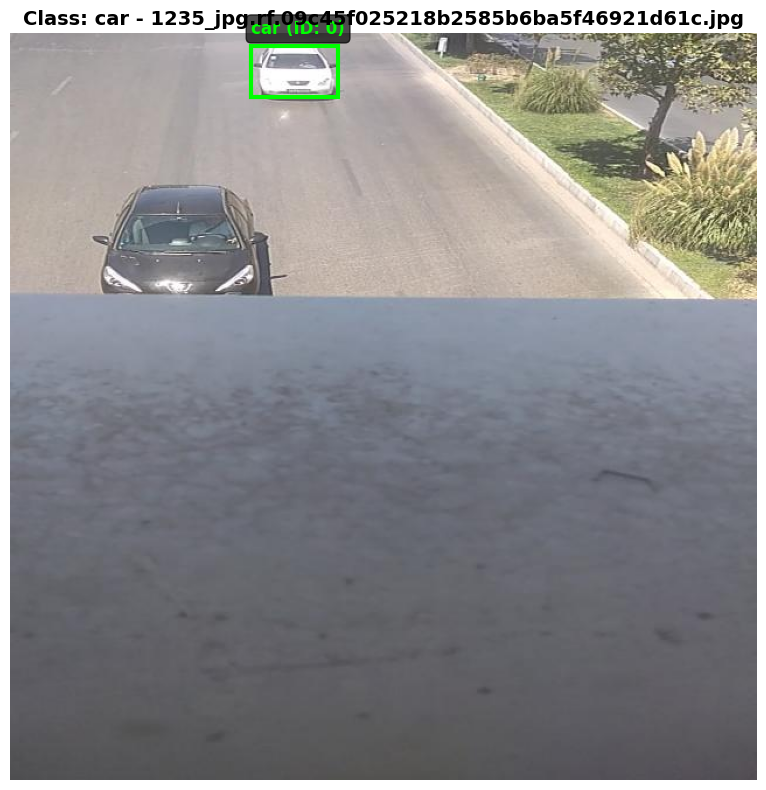

Visualizing Class 1: motor


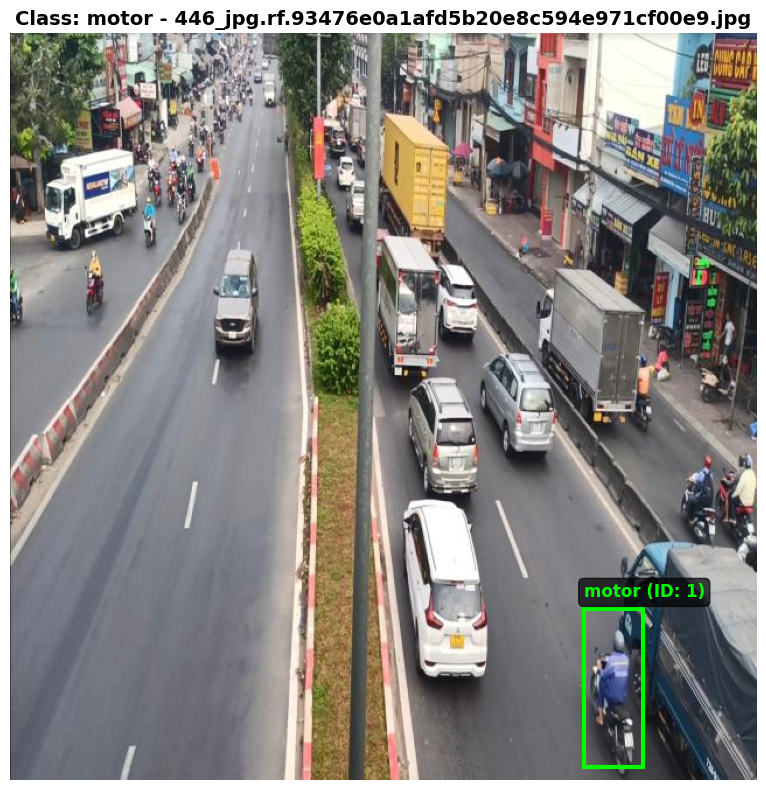

Visualizing Class 2: truck


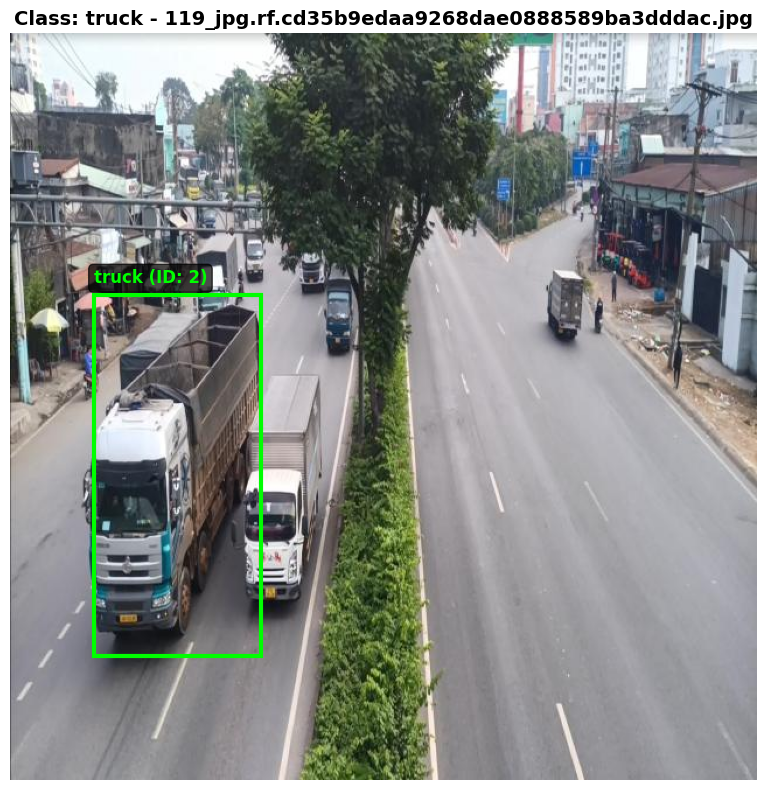

Visualizing Class 3: bus


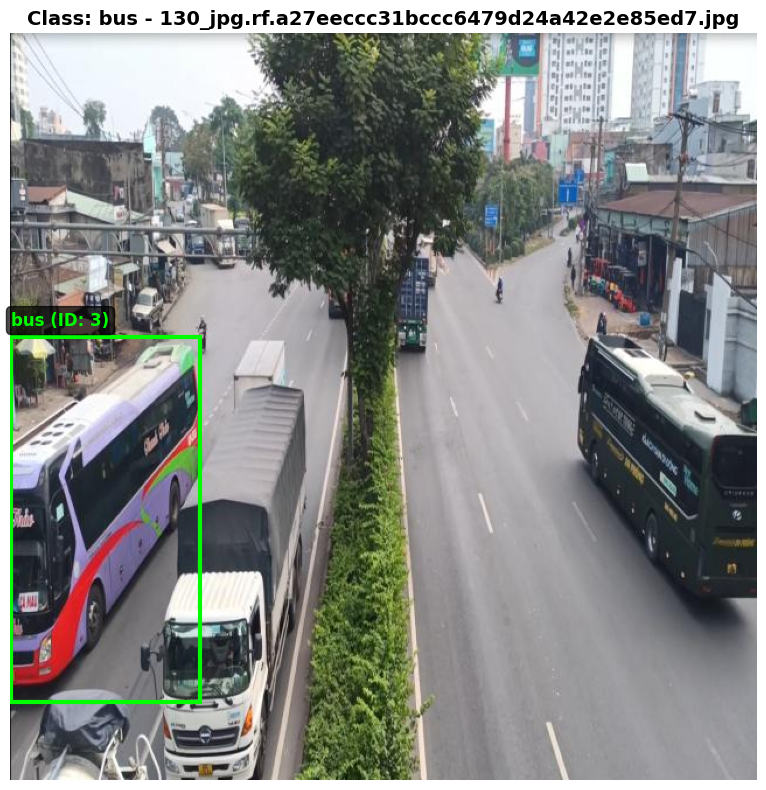

In [18]:
class_samples=get_one_image_per_class(data_set['train_images'],data_set['train_labels'],data_set['names'])
for cls_id in sorted(class_samples.keys()):
    print(f"  Class {cls_id}: {data_set['names'][cls_id] if cls_id < len(data_set['names']) else 'Unknown'}")

for cls_id in sorted(class_samples.keys()):
    image_path, label_path, bbox_line = class_samples[cls_id]
    print(f"Visualizing Class {cls_id}: {data_set['names'][cls_id] if cls_id < len(data_set['names']) else 'Unknown'}")
    visualize_image_with_bbox(image_path, label_path, bbox_line, data_set['names'])


In [ ]:
MODEL='yolov8m.pt'
TRAINING_CONFIG_PATH = '/kaggle/working/testtt/model_detection/configs/training_config.yaml'
DATA_YAML_PATH='/kaggle/working/data.yaml'
best_model=train_model(weights=MODEL,training_config_path=TRAINING_CONFIG_PATH)

In [8]:
def show_image(image_path, title="Image", figsize=(10, 10)):
    if os.path.exists(image_path):
        img = Image.open(image_path)
        plt.figure(figsize=figsize)
        plt.imshow(img)
        plt.axis('off') # Tắt trục tọa độ cho đẹp
        plt.title(title, fontsize=14, fontweight='bold')
        plt.show()
    else:
        print(f"Không tìm thấy file: {image_path}")

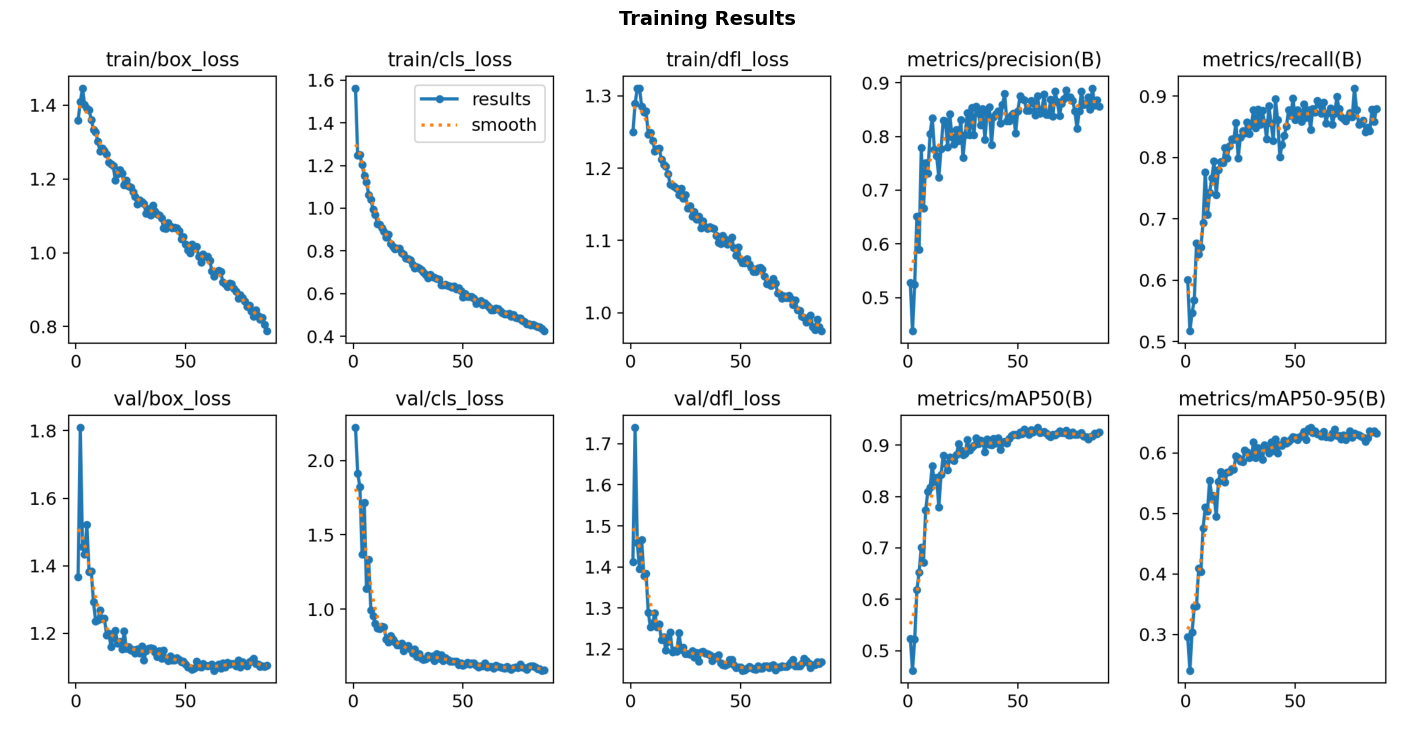

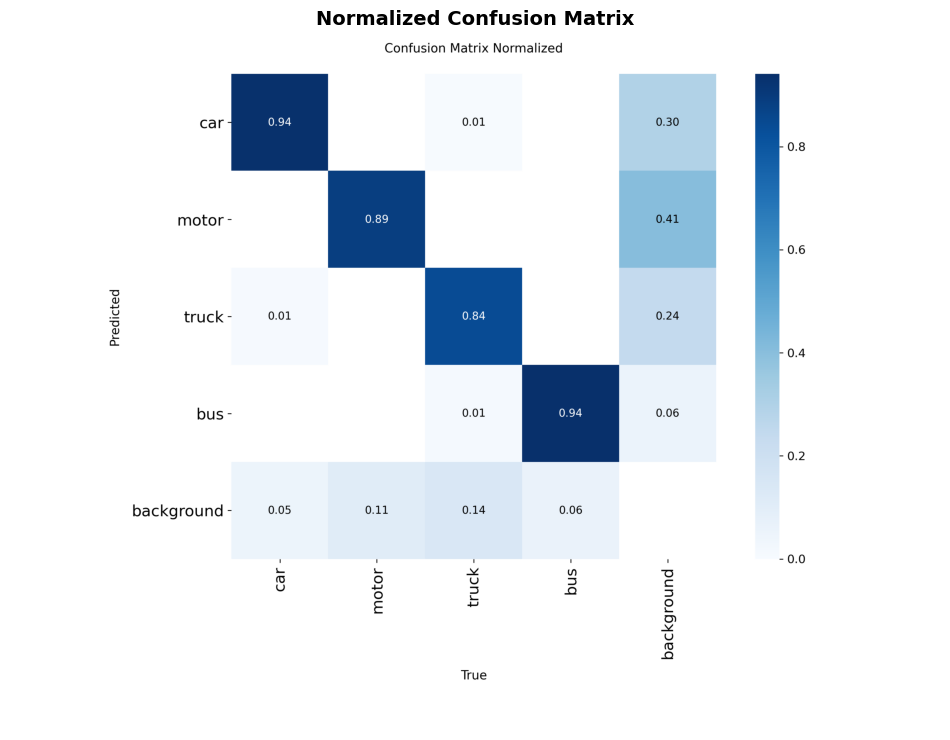

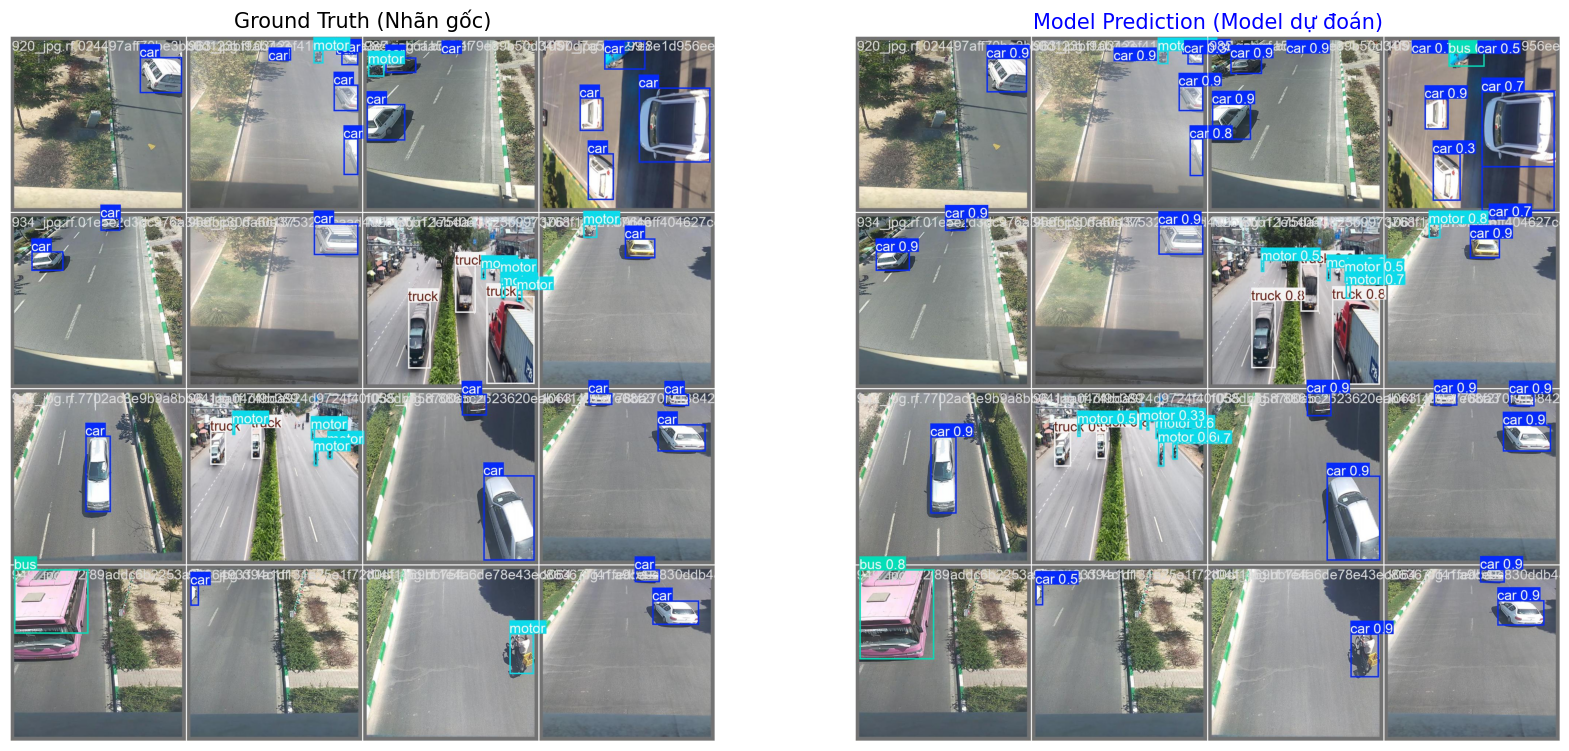

In [6]:
train_dir = 'runs/detect/train'
show_image(os.path.join(train_dir, 'results.png'), "Training Results", figsize=(18, 10))
show_image(os.path.join(train_dir, 'confusion_matrix_normalized.png'), "Normalized Confusion Matrix", figsize=(12, 10))
val_pred_path = os.path.join(train_dir, 'val_batch0_pred.jpg')
val_label_path = os.path.join(train_dir, 'val_batch0_labels.jpg')
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(Image.open(val_label_path))
axes[0].set_title("Ground Truth (Nhãn gốc)", fontsize=15)
axes[0].axis('off')  
axes[1].imshow(Image.open(val_pred_path))
axes[1].set_title("Model Prediction (Model dự đoán)", fontsize=15, color='blue')
axes[1].axis('off')
plt.show()

In [13]:
model = YOLO('/Users/koiita/Downloads/CV_trafficdetection-main/models/best.pt')
metrics = model.val(data='/Users/koiita/Downloads/traffic_yolo_detect/data/data_set/data.yaml',conf=0.4) 
class_names = model.names
data = []

box_p = metrics.box.p
box_r = metrics.box.r
box_f1 = metrics.box.f1
box_ap50 = metrics.box.ap50
box_map = metrics.box.maps

for i, class_name in class_names.items():
    try:
        if i >= len(box_ap50):
            continue

        f1_data = box_f1[i]

        if np.ndim(f1_data) > 0:
            best_idx = np.argmax(f1_data)
            p_best = box_p[i][best_idx]
            r_best = box_r[i][best_idx]
            f1_best = f1_data[best_idx]
        else:
            p_best = box_p[i]
            r_best = box_r[i]
            f1_best = box_f1[i]

        map50 = box_ap50[i]
        map5095 = box_map[i]

        data.append({
            "Class ID": i,
            "Class Name": class_name,
            "Precision": round(float(p_best), 4),
            "Recall": round(float(r_best), 4),
            "F1-Score": round(float(f1_best), 4),
            "mAP@0.5": round(float(map50), 4),
            "mAP@0.5:0.95": round(float(map5095), 4)
        })

    except Exception as e:
        print(f"Error processing class '{class_name}': {e}")
        continue

if data:
    df = pd.DataFrame(data)
    print(df.to_string(index=False))
    df.to_csv("precision_recall_per_class_fixed.csv", index=False)
else:
    print("No data extracted.")

Ultralytics 8.3.232 🚀 Python-3.12.7 torch-2.9.1 CPU (Apple M1)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 191.4±87.7 MB/s, size: 59.6 KB)
val: Scanning /Users/koiita/Downloads/traffic_yolo_detect/data/data_set/valid/labels.cache... 156 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 156/156 321.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 12.9s/it 2:094.2s
                   all        156        703      0.868      0.856      0.903      0.664
                   car        122        282      0.908      0.876      0.921      0.756
                 motor         68        211      0.833      0.796      0.873      0.516
                 truck         80        176      0.835      0.869      0.884      0.662
                   bus         26         34      0.896      0.882      0.932      0.723
Speed: 1.3ms preproces

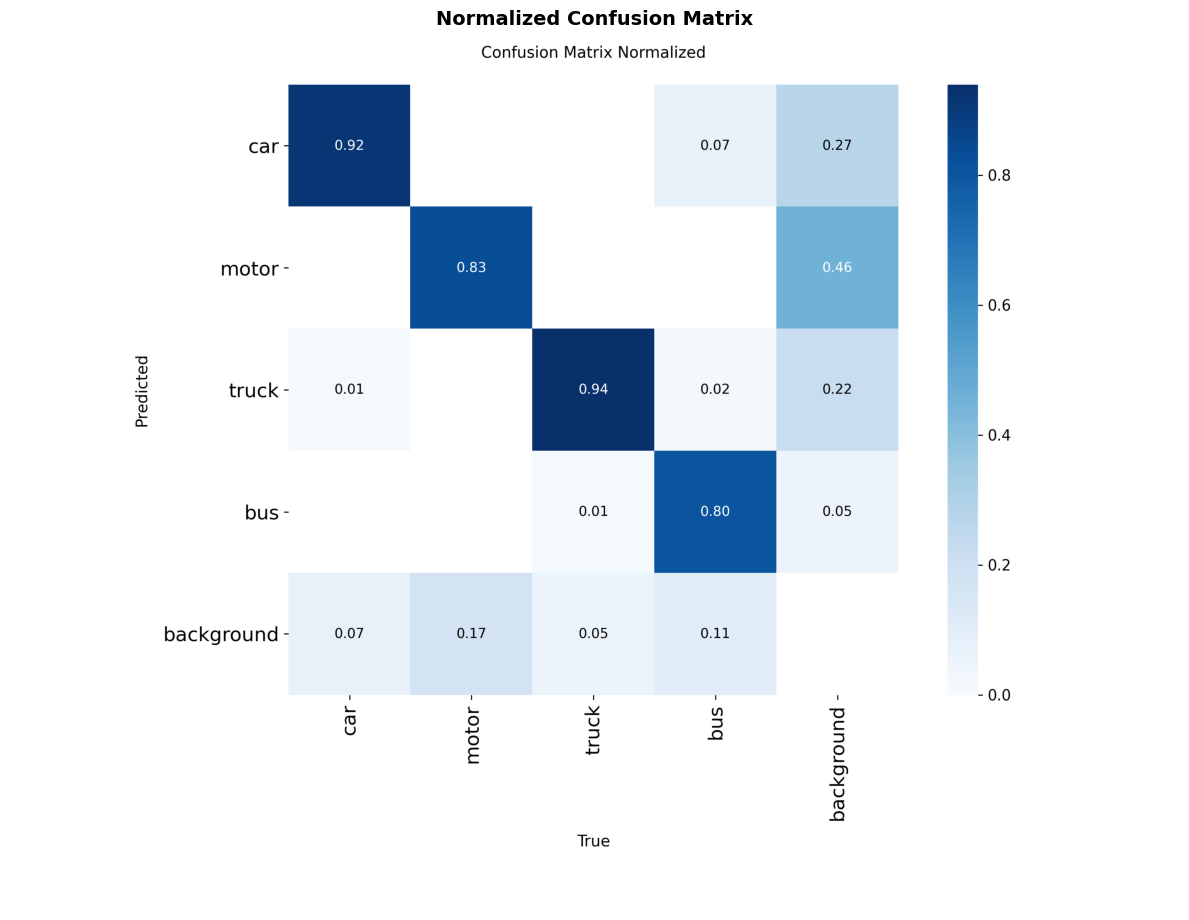

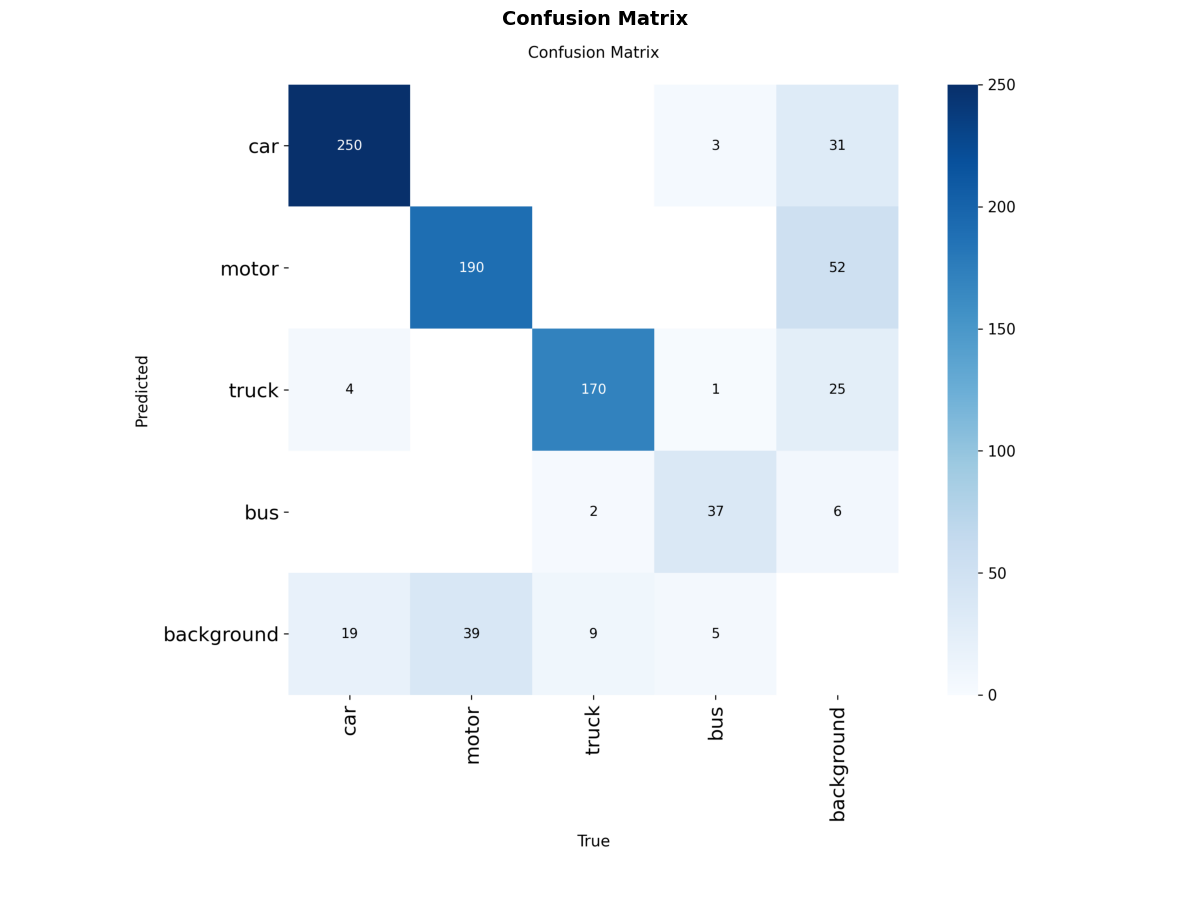

In [15]:

%matplotlib inline
from IPython.display import display

def show_image(image_path, title="Image", figsize=(10, 10)):
    if os.path.exists(image_path):
        img = Image.open(image_path)
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Không tìm thấy file: {image_path}")

show_image('/Users/koiita/Downloads/CV_trafficdetection-main/model_detection/runs/detect/val14/confusion_matrix_normalized.png', "Normalized Confusion Matrix", figsize=(12, 10))
show_image('/Users/koiita/Downloads/CV_trafficdetection-main/model_detection/runs/detect/val14/confusion_matrix.png', "Confusion Matrix", figsize=(12, 10))

In [14]:
model = YOLO('/Users/koiita/Downloads/CV_trafficdetection-main/models/best.pt')
metrics = model.val(data='/Users/koiita/Downloads/traffic_yolo_detect/data/data_set/data.yaml',conf=0.4,split='test') 
class_names = model.names
data = []

box_p = metrics.box.p
box_r = metrics.box.r
box_f1 = metrics.box.f1
box_ap50 = metrics.box.ap50
box_map = metrics.box.maps

for i, class_name in class_names.items():
    try:
        if i >= len(box_ap50):
            continue

        f1_data = box_f1[i]

        if np.ndim(f1_data) > 0:
            best_idx = np.argmax(f1_data)
            p_best = box_p[i][best_idx]
            r_best = box_r[i][best_idx]
            f1_best = f1_data[best_idx]
        else:
            p_best = box_p[i]
            r_best = box_r[i]
            f1_best = box_f1[i]

        map50 = box_ap50[i]
        map5095 = box_map[i]

        data.append({
            "Class ID": i,
            "Class Name": class_name,
            "Precision": round(float(p_best), 4),
            "Recall": round(float(r_best), 4),
            "F1-Score": round(float(f1_best), 4),
            "mAP@0.5": round(float(map50), 4),
            "mAP@0.5:0.95": round(float(map5095), 4)
        })

    except Exception as e:
        print(f"Error processing class '{class_name}': {e}")
        continue

if data:
    df = pd.DataFrame(data)
    print(df.to_string(index=False))
    df.to_csv("precision_recall_per_class_fixed.csv", index=False)
else:
    print("No data extracted.")

Ultralytics 8.3.232 🚀 Python-3.12.7 torch-2.9.1 CPU (Apple M1)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 179.0±40.2 MB/s, size: 55.0 KB)
val: Scanning /Users/koiita/Downloads/traffic_yolo_detect/data/data_set/test/labels... 156 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 156/156 1.4Kit/s 0.1s<0.1s
val: New cache created: /Users/koiita/Downloads/traffic_yolo_detect/data/data_set/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 12.6s/it 2:063.6s
                   all        156        729      0.875      0.846      0.893      0.656
                   car        122        273      0.901      0.899      0.936      0.758
                 motor         74        229      0.831      0.775      0.825      0.433
                 truck         92        181      0.885      0.928      0.952       0.74
               

In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8m.pt')
source_img = 'User/koiita/Downloads/traffic_yolo_detect/data/data_set/test/images/' 
results = model.predict(
    source=source_img, 
    save=True, 
    conf=0.4, 
    classes=[2, 3, 5, 7], 
    project='runs/detect',
    name='pretrained_visual_check'
)
